# Longitudinal analysis — final, 2 October 2026

Read this first when returning to the project.

## The two questions

**Q1. Do LH-intact and RH-intact patients differ over time, and does it matter?**

**Q2. Are more symmetrically represented categories (house, object) or more
asymmetrically lateralized ones (face, word) more susceptible after pediatric
resection?** In adults the lateralized categories are the vulnerable ones. For
children it is open. The hypothesis: the two hemispheres are collaborative, not
redundant, so losing one forces symmetric categories to reorganize, while
lateralized categories can relocate more intact.

## Where things stood on 2 October 2026

**Single takeaway sent to Marlene:** in children with OTC resection, the
representations of categories normally shared by both hemispheres are less
stable over time than those of lateralized categories.

- **Between-category similarity, stability over time.** In all five patients
  the arrangement of the four categories is more stable between scans in face
  and word regions than in house and object regions. Same direction as
  February (Desikan-Killiany parcels) and on this pipeline (7 mm spheres).
  The patients carrying it changed: 004 and 010 were strongest in February,
  008 and 079 now.
- **Against controls.** In February the patient gap exceeded the control gap
  (difference of differences -0.420, 95% CI -0.660 to -0.191). On this
  pipeline controls also show a gap (-0.123, 5 of 8), so that is not
  reproduced. Control n is not the reason: 9 controls then, 8 now.
- **Peak movement.** Patient peaks move further than control peaks at most
  regions, carried by one or two patients per group.
- **Selectivity.** RH-intact patients rise at VWFA, FFA and PPA; LH-intact
  show no consistent direction.
- **Selective voxels.** PPA gains in all five patients.
- **Side typicality (Q1).** No pattern: two LH-intact patients became more
  side-typical, one RH-intact patient much less.

The summary deck is `longitudinal_summary_2026-10-02_v3.pptx`.

## Terminology

"Geometry preservation" in older notes is the same thing as the stability of
**between-category similarity** here: built from the same six pairwise
correlations the cross-sectional paper uses (manuscript para 67), compared
across a subject's two scans instead of across groups.

## Cohort

| group | n | subjects |
|---|---|---|
| LH-intact (right resection) | 3 | sub-004 (UD, 5 sessions), sub-008, sub-079 (EC) |
| RH-intact (left resection) | 2 | sub-010 (FD), sub-021 (TC, 3 sessions) |
| controls | 8 | sub-018, 022, 025, 052, 058, 062, 064, 068 |
| nonOTC | 9 | visual comparison only, never tested |

**sub-079 is surgery right / intact left** in both `sub_info.csv` and
`patient_id_key.csv`. Notes before October 2026, and the February figure, have
it as intact right. Anything computed with that assignment is wrong for Q1.

**sub-108 session 2 is held out.** Its HighLevel z range is +/-48 against
+/-6 to 15 in every other patient. Its three single runs are normal (+/-5 to
8), so the inflation is created at the higher-level stage. Reinstating it gives
6 patients, balanced 3 and 3.

**sub-025 and sub-064** change scanner between sessions. Kept in.

## Statistical framework

Primary is the per-patient control bootstrap, set in April 2026: each patient
checked individually against the control distribution (10,000 iterations),
not pooled group means. Then within-patient symmetric minus asymmetric, paired
across patients; then the patient gap against the control gap. With five
patients the count (how many of five go the same way) carries more than any
p-value. A sign-flip permutation at n = 5 cannot go below about .031.

## Decisions taken

- First versus last session, not consecutive pairs. Averaging consecutive
  pairs dilutes subjects with closely spaced sessions (sub-021: -0.25
  consecutive vs -0.58 first-versus-last).
- No ComBat. The harmonized files hold one session per subject. Within-subject
  differencing cancels the additive scanner term but not the variance term.
- Peak location uses a fixed control reference (control first session).
- No laterality index or gradient tests: too sensitive to interpret at n = 5.
- Whole-OTC (Rosenke) uses the MNI map at every session because the mask is
  MNI. ROI measures use native `_ses01` maps. So the two are aligned
  differently.

## Traps found today

- `D_liu/verified/02_tfce_analyses_dontuse_useharmony.py` uses the walrus
  operator and will not import on Python 3.7 (`brainiak_env`). Its functions
  are inlined below instead.
- `zstat1_ses01_mni.nii.gz` does not exist. Only `zstat1_mni.nii.gz`
  (MNI), `zstat1_ses01.nii.gz` (native, first-session space) and `zstat1.nii.gz`.
- Session directories are zero-padded (`ses-01`); build paths with `%02d`.
- The harmonized CSVs (`*_harmonized*.csv`) carry one session per subject and
  cannot support a longitudinal analysis. Use `rsa_v1.csv` and
  `univariate_v1.csv`.
- `B_analyses/07_liu_distinctiveness.py` and `08_geometry_preservation.py`
  overwrite their CSVs rather than appending. Back up before rerunning.

## Related files

| file | what |
|---|---|
| `C_results/01_select_visuals.ipynb` | February figures (Desikan pipeline) |
| `long_pt/B_analyses/04_age.ipynb` | original scan-timepoints figure |
| `final_figures.ipynb` cell 6 | the cross-sectional `panel_row` this ports |
| Google Slides "Longitudinal Patient" | Fall 2025 to Feb 2026 log; slides 66-99 current, 95 has February gaps |
| `D_liu/otc_rsm_persession.csv` | written here: whole-OTC values per session |
| `D_liu/longitudinal_q12_results.csv` | written here: every test |

## Outstanding

1. Preprocess ses-01 for controls sub-038, sub-059, sub-067 (raw data exists in
   `/lab_data/behrmannlab/hemi/Raw`). Takes controls from 8 toward 11.
2. Fix sub-108 ses-02 at the higher-level stage.
3. Decide whether the February or current pipeline is the reported one, on
   grounds other than which shows the control difference.
4. Peak movement: check whether the same patients move most across regions,
   and whether they are the ones with the least stable between-category
   similarity.
5. ComBat, if the longitudinal section must be on the manuscript's scale.

In [1]:
import sys, warnings, importlib.util
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr
from pathlib import Path
warnings.filterwarnings('ignore')

GIT  = Path('/user_data/csimmon2/git_repos/sym_pt')
PROC = Path('/user_data/csimmon2/sym_pt')
D_LIU= GIT/'D_liu'
sys.path.insert(0,str(GIT))
from params import processed_dir

UNIVAR = D_LIU/'univariate_v1.csv'
RSA    = D_LIU/'rsa_v1.csv'
PEAKMNI= Path(processed_dir)/'group_results'/'peak_coords'/'peak_coords_mni.csv'
SUBINFO= GIT/'sub_info.csv'
FIGDIR = GIT/'C_results'/'figures'/'longitudinal_final'; FIGDIR.mkdir(parents=True,exist_ok=True)
OUT    = D_LIU/'longitudinal_q12_results.csv'

EXCLUDE=['sub-017','sub-091','sub-095','sub-096','sub-027','sub-084']
EXCLUDE_SES=[('sub-108',2)]
ROIS=['face_FFA','house_PPA_strict','object_LOC','word_VWFA']
LAB={'face_FFA':'FFA','house_PPA_strict':'PPA','object_LOC':'LOC','word_VWFA':'VWFA'}
OWN={'face_FFA':'face','house_PPA_strict':'house','object_LOC':'object','word_VWFA':'word'}
ASYM=['face_FFA','word_VWFA']; SYM=['house_PPA_strict','object_LOC']
CATS=['face','house','object','word']
PAIRS=['face-house','face-object','face-word','house-object','house-word','object-word']
N_BOOT=10000; N_PERM=10000
RNG=np.random.RandomState(42)
COL={'control':'#7A7A7A','LH-intact':'#7398AF','RH-intact':'#EE7183','nonOTC':'#FF9800'}
print('asymmetric:',[LAB[r] for r in ASYM],'| symmetric:',[LAB[r] for r in SYM])

asymmetric: ['FFA', 'VWFA'] | symmetric: ['PPA', 'LOC']


In [2]:
# ── load, build change scores ───────────────────────────────────────────────
def age_table():
    si=pd.read_csv(SUBINFO); si['subject_id']=si['sub'].astype(str)
    si['ses_num']=pd.to_numeric(si['ses'].astype(str).str.extract(r'(\d+)',expand=False),
                                errors='coerce').astype('Int64')
    return si[['subject_id','ses_num','age']].dropna().drop_duplicates(['subject_id','ses_num'])

def load(p):
    d=pd.read_csv(p); d=d[~d.subject_id.isin(EXCLUDE)].copy()
    d['ses_num']=pd.to_numeric(d['session'],errors='coerce').astype('Int64')
    for s,x in EXCLUDE_SES: d=d[~((d.subject_id==s)&(d.ses_num==x))]
    d=d.drop(columns=[c for c in ('age',) if c in d.columns])
    return d.merge(age_table(),on=['subject_id','ses_num'],how='left')

def label(r):
    if r['status']=='control': return 'control'
    if r['group']=='nonOTC':   return 'nonOTC'
    return 'LH-intact' if r['intact_hemi']=='left' else 'RH-intact'

def own_hemi(df):
    c=df[df.status=='control']; p=df[df.status!='control']
    p=p[((p.intact_hemi=='left')&(p.hemi=='l'))|((p.intact_hemi=='right')&(p.hemi=='r'))]
    return pd.concat([c,p],ignore_index=True)

def change(df,val,keys=('subject_id','hemi','category'),sqrt=False):
    keys=list(keys); out=[]
    for k,g in df.groupby(keys,dropna=True):
        g=g.drop_duplicates('ses_num').sort_values('ses_num')
        if len(g)<2: continue
        a,b=g.iloc[0],g.iloc[-1]
        if pd.isna(a[val]) or pd.isna(b[val]): continue
        va,vb=float(a[val]),float(b[val])
        if sqrt: va,vb=np.sqrt(max(va,0)),np.sqrt(max(vb,0))
        rec=dict(zip(keys,k if isinstance(k,tuple) else (k,)))
        rec.update(v_first=va,v_last=vb,delta=vb-va,group=a['group'],status=a['status'],
                   intact_hemi=a['intact_hemi'],
                   age=float(b['age']) if not pd.isna(b['age']) else np.nan,
                   interval=(float(b['age']-a['age']) if not pd.isna(a['age']) else np.nan))
        rec['grp']=label(rec); out.append(rec)
    return own_hemi(pd.DataFrame(out))

uni=load(UNIVAR); rsa=load(RSA)
uni_u=uni.drop_duplicates(['subject_id','ses_num','hemi','category'])
rsa_u=rsa.drop_duplicates(['subject_id','ses_num','hemi','category'])
btw_u=rsa.drop_duplicates(['subject_id','ses_num','hemi','category','pair'])

CH={}
CH['peak_selectivity']=change(uni_u,'peak_z')
CH['voxel_count_sqrt']=change(uni_u,'volume',sqrt=True)
mb=(btw_u[btw_u.pair.isin(PAIRS)]
    .groupby(['subject_id','ses_num','hemi','category','status','group','intact_hemi','age'],
             as_index=False).fisher_r.mean())
CH['mean_between']=change(mb,'fisher_r')
CH['between_pairs']=change(btw_u,'fisher_r',keys=('subject_id','hemi','category','pair'))

# peak location: fixed control reference
if PEAKMNI.exists():
    mni=load(PEAKMNI)
    cf=(mni[mni.status=='control'].sort_values('ses_num')
        .groupby(['subject_id','hemi','category']).head(1))
    CEN={}
    for (h,roi),g in cf.groupby(['hemi','category']):
        v=g[['peak_x_mni','peak_y_mni']].dropna().values
        if len(v)>=3: CEN[(h,roi)]=v.mean(0)
    rows=[]
    for (s,h,roi),g in mni.groupby(['subject_id','hemi','category']):
        if (h,roi) not in CEN: continue
        g=g.drop_duplicates('ses_num').sort_values('ses_num')
        if len(g)<2: continue
        a,b=g.iloc[0],g.iloc[-1]
        pa=a[['peak_x_mni','peak_y_mni']].astype(float).values
        pb=b[['peak_x_mni','peak_y_mni']].astype(float).values
        if np.isnan(pa).any() or np.isnan(pb).any(): continue
        cen=CEN[(h,roi)]
        rec=dict(subject_id=s,hemi=h,category=roi,
                 v_first=float(np.linalg.norm(pa-cen)),v_last=float(np.linalg.norm(pb-cen)),
                 group=a['group'],status=a['status'],intact_hemi=a['intact_hemi'],
                 age=float(b['age']) if not pd.isna(b['age']) else np.nan)
        rec['delta']=rec['v_last']-rec['v_first']; rec['grp']=label(rec); rows.append(rec)
    CH['peak_location']=own_hemi(pd.DataFrame(rows))
else:
    print('MISSING',PEAKMNI); CH['peak_location']=pd.DataFrame()

# peak movement: distance the peak voxel moved, first to last session, mm.
# Native coordinates, which are in each subject's first-session space (the
# _ses01 maps), so distances are comparable within a subject.
rows=[]
PCOLS=['peak_x_native','peak_y_native','peak_z_native']
for (s_,h,roi),g in uni_u.groupby(['subject_id','hemi','category']):
    g=g.drop_duplicates('ses_num').sort_values('ses_num')
    if len(g)<2: continue
    a,b=g.iloc[0],g.iloc[-1]
    pa=a[PCOLS].astype(float).values; pb=b[PCOLS].astype(float).values
    if np.isnan(pa).any() or np.isnan(pb).any(): continue
    rec=dict(subject_id=s_,hemi=h,category=roi,delta=float(np.linalg.norm(pb-pa)),
             group=a['group'],status=a['status'],intact_hemi=a['intact_hemi'],
             age=float(b['age']) if not pd.isna(b['age']) else np.nan)
    rec['grp']=label(rec); rows.append(rec)
CH['peak_movement']=own_hemi(pd.DataFrame(rows))

for k,v in CH.items(): print(f'{k:20s} rows {len(v):5d} subjects {v.subject_id.nunique() if len(v) else 0:3d}')

peak_selectivity     rows   360 subjects  22
voxel_count_sqrt     rows   360 subjects  22
mean_between         rows   231 subjects  13
between_pairs        rows  1386 subjects  13
peak_location        rows   360 subjects  22
peak_movement        rows   360 subjects  22


## Measure 6. Geometry preservation

The correlation between a subject's six between-category similarities at the
first session and the same six at the last, within each ROI. Higher means the
representational structure is more preserved. This is the measure with a prior
result (February 2026) and the only one with no cross-sectional counterpart.

In [3]:
def geometry(df):
    out=[]
    for (s,h,roi),g in df.groupby(['subject_id','hemi','category']):
        piv=g.pivot_table(index='ses_num',columns='pair',values='fisher_r').reindex(columns=PAIRS)
        ss=sorted(piv.index)
        if len(ss)<2: continue
        a,b=piv.loc[ss[0]].values,piv.loc[ss[-1]].values
        if np.isnan(a).any() or np.isnan(b).any(): continue
        meta=g.iloc[0]
        rec=dict(subject_id=s,hemi=h,category=roi,delta=float(pearsonr(a,b)[0]),
                 group=meta['group'],status=meta['status'],intact_hemi=meta['intact_hemi'],
                 age=float(meta['age']) if not pd.isna(meta['age']) else np.nan)
        rec['grp']=label(rec); out.append(rec)
    return own_hemi(pd.DataFrame(out))

CH['geometry']=geometry(rsa)
g=CH['geometry']
print('geometry rows',len(g),'| subjects',g.subject_id.nunique())
print()
print('Per-patient geometry preservation, this run:')
pt=g[g.status!='control']
print(pt[pt.category.isin(ROIS)].pivot_table(index=['grp','subject_id'],
      columns='category',values='delta').rename(columns=LAB).round(3).to_string())

FEB_GAP={'sub-004':-0.537,'sub-010':-0.764,'sub-021':-0.338,'sub-079':-0.322,
         'sub-008':-0.20}
# 004, 010, 021, 079: Google deck "Longitudinal Patient", slide 95 (exact).
# 008: read off the February figure (01_select_visuals.ipynb cell 4); not on slide 95.
_now={}
for s_,gg in pt[pt.category.isin(ROIS)].groupby('subject_id'):
    v=gg.set_index('category').delta
    _now[s_]=np.mean([v.get('house_PPA_strict'),v.get('object_LOC')])-             np.mean([v.get('face_FFA'),v.get('word_VWFA')])
cmp_=pd.DataFrame({'february_gap':pd.Series(FEB_GAP),'october_gap':pd.Series(_now)}).round(3)
print('Symmetric minus asymmetric, February vs this run:')
print(cmp_.to_string())
print('negative in February:',int((cmp_.february_gap<0).sum()),'/ 5   '
      'negative now:',int((cmp_.october_gap<0).sum()),'/ 5')
print('February reported: symmetric < asymmetric in 5/5, paired t(4)=4.378, p=.012.')
print('Computed on Desikan-Killiany parcels at 75th percentile, not these 7 mm spheres.')

geometry rows 231 | subjects 13

Per-patient geometry preservation, this run:
category                FFA    PPA    LOC   VWFA
grp       subject_id                            
LH-intact sub-004     0.854  0.533  0.447  0.286
          sub-008     0.054 -0.485 -0.616  0.062
          sub-079     0.760  0.617 -0.601  0.747
RH-intact sub-010    -0.198 -0.433  0.253  0.324
          sub-021     0.981  0.276  0.408  0.857
Symmetric minus asymmetric, February vs this run:
         february_gap  october_gap
sub-004        -0.537       -0.080
sub-008        -0.200       -0.608
sub-010        -0.764       -0.152
sub-021        -0.338       -0.577
sub-079        -0.322       -0.746
negative in February: 5 / 5   negative now: 5 / 5
February reported: symmetric < asymmetric in 5/5, paired t(4)=4.378, p=.012.
Computed on Desikan-Killiany parcels at 75th percentile, not these 7 mm spheres.


## Measure 7. Side typicality and consistency, per session

Follows `H_RosenkeRSM/otc_rsm_rosenke.py`: the four category-versus-all-others
maps (copes 6 to 9) over the whole OTC mask, correlated across categories
within subject, giving six off-diagonal values per hemisphere per session.

Side typicality is the correlation with same-side control hemispheres minus the
correlation with opposite-side ones, so a uniform drop in similarity to all
controls subtracts out. Consistency is each subject's mean correlation with
others in their own group. Both are computed per session and differenced.

Deliberately unharmonized, as in the source script: ComBat adjusts each
category map separately, which would distort a correlation across categories.

In [4]:
# ── Rosenke per session. Functions inlined from
#    D_liu/verified/02_tfce_analyses_dontuse_useharmony.py so the module is not
#    imported: it uses the walrus operator and will not parse on Python 3.7.
ROSENKE_OK = True
try:
    import nibabel as nib
    from nilearn import datasets as nl_datasets
    from nilearn.image import resample_to_img
except ImportError as e:
    ROSENKE_OK = False
    print('nibabel/nilearn unavailable:', e)

COPES_OTHERS = {'face': 6, 'house': 7, 'object': 8, 'word': 9}
RPAIRS = [(a, b) for i, a in enumerate(CATS) for b in CATS[i+1:]]
PC = [f'{a}-{b}' for a, b in RPAIRS]

VOTC_LABEL_NAMES = [
    'Temporal Fusiform Cortex, anterior division',
    'Temporal Fusiform Cortex, posterior division',
    'Temporal Occipital Fusiform Cortex',
    'Parahippocampal Gyrus, anterior division',
    'Parahippocampal Gyrus, posterior division',
    'Lingual Gyrus',
    'Lateral Occipital Cortex, superior division',
    'Lateral Occipital Cortex, inferior division',
]

def build_otc_masks(outdir):
    at = nl_datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
    img = at.maps if isinstance(at.maps, nib.Nifti1Image) else nib.load(at.maps)
    data = img.get_fdata(); labels = at.labels
    full = np.zeros(data.shape, dtype=bool)
    for name in VOTC_LABEL_NAMES:
        hit = [i for i, l in enumerate(labels) if name in l]
        if hit: full |= (data == hit[0])
    mid = data.shape[0] // 2
    out = {}
    outdir.mkdir(parents=True, exist_ok=True)
    for hemi, slc in [('l', slice(mid, None)), ('r', slice(None, mid))]:
        m = full.copy(); m[slc] = False
        pth = outdir / f'votc_{hemi}_mask.nii.gz'
        nib.save(nib.Nifti1Image(m.astype(np.uint8), img.affine), pth)
        out[hemi] = pth
        print(f'  {hemi}: {int(m.sum())} voxels -> {pth.name}')
    return out

def zstat_path(sid, session, first_session, cope):
    # Every session uses zstat1_mni.nii.gz because the OTC mask is MNI.
    # zstat1_ses01_mni.nii.gz does not exist; zstat1_ses01.nii.gz is native.
    # Directories are zero-padded (ses-01), so the integer must be formatted.
    return (Path(processed_dir)/sid/('ses-%02d' % int(session))/'derivatives'/'fsl'
            /'loc'/'HighLevel.gfeat'/('cope%d.feat' % cope)/'stats'/'zstat1_mni.nii.gz')

def od_for(sid, session, first_session, mask_path):
    paths = [zstat_path(sid, session, first_session, COPES_OTHERS[c]) for c in CATS]
    if not all(Path(p).exists() for p in paths): return None
    img0 = nib.load(str(paths[0]))
    m = resample_to_img(nib.load(str(mask_path)), img0,
                        interpolation='nearest').get_fdata() > 0.5
    X = np.vstack([nib.load(str(p)).get_fdata()[m] for p in paths])
    good = np.isfinite(X).all(0); X = X[:, good]
    if X.shape[1] < 50 or (X.std(axis=1) == 0).any(): return None
    rsm = np.arctanh(np.clip(np.corrcoef(X), -0.999, 0.999))
    idx = {c: i for i, c in enumerate(CATS)}
    return np.array([rsm[idx[a], idx[b]] for a, b in RPAIRS])

rsm_long = pd.DataFrame()
if ROSENKE_OK:
    masks = build_otc_masks(Path(processed_dir)/'group_results'/'otc_rsm_long')
    si2 = pd.read_csv(SUBINFO); si2['subject_id'] = si2['sub'].astype(str)
    si2['ses_num'] = pd.to_numeric(
        si2['ses'].astype(str).str.extract(r'(\d+)', expand=False), errors='coerce').astype(int)
    si2 = si2[~si2.subject_id.isin(EXCLUDE)]
    for s_, x_ in EXCLUDE_SES: si2 = si2[~((si2.subject_id == s_) & (si2.ses_num == x_))]
    nses = si2.groupby('subject_id').ses_num.nunique()
    si2 = si2[si2.subject_id.isin(nses[nses >= 2].index)]

    recs, missing = [], []
    for sid, g in si2.groupby('subject_id'):
        g = g.sort_values('ses_num'); first = int(g.ses_num.iloc[0]); meta = g.iloc[0]
        hemis = (['l','r'] if meta['group'] == 'control'
                 else (['l'] if meta['intact_hemi'] == 'left' else ['r']))
        for _, r in g.iterrows():
            for h in hemis:
                e = od_for(sid, int(r.ses_num), first, masks[h])
                if e is None:
                    missing.append((sid, int(r.ses_num), h)); continue
                recs.append(dict(subject_id=sid, ses_num=int(r.ses_num), hemi=h,
                                 group=meta['group'],
                                 status=('control' if meta['group'] == 'control' else 'patient'),
                                 intact_hemi=meta['intact_hemi'], age=float(r['age']),
                                 **{k: val for k, val in zip(PC, e)}))
    rsm_long = pd.DataFrame(recs)
    rsm_long.to_csv(D_LIU/'otc_rsm_persession.csv', index=False)
    print('per-session whole-OTC rows:', len(rsm_long),
          '| subjects:', rsm_long.subject_id.nunique() if len(rsm_long) else 0)
    if missing:
        print('no usable maps for', len(missing), 'subject x session x hemi cells:')
        for mm in missing[:12]: print('  ', mm)

/home/csimmon2/anaconda3/envs/brainiak_env/lib/python3.7/site-packages/nilearn/__init__.py:67: FutureWarning: Python 3.7 support is deprecated and will be removed in release 0.12 of Nilearn. Consider switching to Python 3.9 or 3.10.
  _python_deprecation_warnings()


  l: 11340 voxels -> votc_l_mask.nii.gz
  r: 11540 voxels -> votc_r_mask.nii.gz
per-session whole-OTC rows: 68 | subjects: 22


In [5]:
if ROSENKE_OK and len(rsm_long):
    ref=(rsm_long[rsm_long.status=='control'].sort_values('ses_num')
         .groupby(['subject_id','hemi']).head(1))
    Lref=ref[ref.hemi=='l']; Rref=ref[ref.hemi=='r']

    def mean_r(vec,refdf,exclude):
        rs=[pearsonr(vec,o[PC].values.astype(float))[0]
            for _,o in refdf.iterrows() if o.subject_id!=exclude]
        return float(np.mean(rs)) if rs else np.nan

    rows=[]
    for _,r in rsm_long.iterrows():
        v=r[PC].values.astype(float)
        same=mean_r(v,Lref if r.hemi=='l' else Rref,r.subject_id)
        opp =mean_r(v,Rref if r.hemi=='l' else Lref,r.subject_id)
        own = rsm_long[(rsm_long.group==r.group)&(rsm_long.ses_num==r.ses_num)
                       &(rsm_long.hemi==r.hemi)]
        cons=mean_r(v,own,r.subject_id)
        rows.append(dict(subject_id=r.subject_id,ses_num=r.ses_num,hemi=r.hemi,
                         group=r.group,status=r.status,intact_hemi=r.intact_hemi,
                         age=r.age,typicality=same-opp,consistency=cons))
    tp=pd.DataFrame(rows); tp['category']='wholeOTC'
    CH['side_typicality']=change(tp,'typicality')
    CH['consistency']=change(tp,'consistency')
    for k in ['side_typicality','consistency']:
        print(f'{k:18s} rows {len(CH[k]):4d} subjects {CH[k].subject_id.nunique()}')
    print()
    print(CH['side_typicality'][['subject_id','grp','v_first','v_last','delta']]
          .round(3).to_string(index=False))
else:
    print('side typicality and consistency not computed')

side_typicality    rows   30 subjects 22
consistency        rows   27 subjects 19

subject_id       grp  v_first  v_last  delta
   sub-018   control    0.575   0.619  0.044
   sub-018   control   -0.407  -0.412 -0.005
   sub-022   control    0.478   0.224 -0.255
   sub-022   control    0.210   0.242  0.033
   sub-025   control    0.483   0.236 -0.247
   sub-025   control   -0.023   0.201  0.225
   sub-052   control    0.331   0.366  0.036
   sub-052   control   -0.122   0.048  0.170
   sub-058   control    0.461   0.316 -0.145
   sub-058   control   -0.011   0.477  0.488
   sub-062   control    0.236   0.243  0.007
   sub-062   control    0.361   0.134 -0.227
   sub-064   control    0.248   0.200 -0.048
   sub-064   control   -0.024   0.184  0.208
   sub-068   control    0.349   0.398  0.050
   sub-068   control    0.209   0.115 -0.094
   sub-004 LH-intact    0.347   0.271 -0.076
   sub-007    nonOTC    0.049   0.007 -0.042
   sub-008 LH-intact   -0.231   0.373  0.604
   sub-010 RH-int

## The three tests

1. Each patient against the control bootstrap CI, individually.
2. Within-patient symmetric minus asymmetric, paired across patients.
3. Difference of differences: the patient gap against the control gap.

In [6]:
results=[]
def rec(**kw):
    base=dict(question=None,measure=None,test=None,group=None,subject=None,level=None,
              value=np.nan,ctrl_mean=np.nan,ci_lo=np.nan,ci_hi=np.nan,outside_ci=np.nan,
              diff=np.nan,d=np.nan,p=np.nan,n=np.nan,note='')
    base.update(kw); return base

def boot_ci(vals,n=N_BOOT,rng=RNG):
    v=np.asarray(vals,float); v=v[~np.isnan(v)]
    if len(v)<3: return np.nan,np.nan
    m=np.array([rng.choice(v,len(v),True).mean() for _ in range(n)])
    return float(np.percentile(m,2.5)),float(np.percentile(m,97.5))

def perm_paired(d,n=N_PERM,rng=RNG):
    d=np.asarray(d,float); d=d[~np.isnan(d)]
    if len(d)<2: return np.nan,np.nan,np.nan
    obs=d.mean(); null=np.array([(d*rng.choice([-1,1],len(d))).mean() for _ in range(n)])
    p=(np.sum(np.abs(null)>=abs(obs))+1)/(n+1)
    return obs,p,(obs/d.std(ddof=1) if d.std(ddof=1)>0 else np.nan)

def perm_ind(a,b,n=N_PERM,rng=RNG):
    a,b=np.asarray(a,float),np.asarray(b,float); a,b=a[~np.isnan(a)],b[~np.isnan(b)]
    if len(a)<2 or len(b)<2: return np.nan,np.nan,np.nan
    obs=a.mean()-b.mean(); pool=np.r_[a,b]; na=len(a)
    null=np.array([ (lambda i: pool[i[:na]].mean()-pool[i[na:]].mean())(rng.permutation(len(pool)))
                    for _ in range(n)])
    p=(np.sum(np.abs(null)>=abs(obs))+1)/(n+1)
    sp=np.sqrt(((len(a)-1)*a.var(ddof=1)+(len(b)-1)*b.var(ddof=1))/(len(a)+len(b)-2))
    return obs,p,(obs/sp if sp>0 else np.nan)

def unibi(ch):
    s=ch[ch.category.isin(ROIS)].copy()
    s['kind']=np.where(s.category.isin(ASYM),'asym','sym')
    return s.groupby(['subject_id','grp','hemi','kind'],as_index=False).delta.mean()

SCALARS=[m for m in ['peak_location','peak_movement','peak_selectivity','voxel_count_sqrt',
                     'mean_between','geometry'] if m in CH and len(CH[m])]

# ── Test 1: each patient vs the control CI, per ROI ───────────────────────
for m in SCALARS:
    ch=CH[m]
    for roi in ROIS:
        for hemi in ['l','r']:
            cv=ch[(ch.grp=='control')&(ch.category==roi)&(ch.hemi==hemi)].delta.dropna().values
            if len(cv)<3: continue
            lo,hi=boot_ci(cv)
            side='LH-intact' if hemi=='l' else 'RH-intact'
            for g in [side,'nonOTC']:
                sub=ch[(ch.grp==g)&(ch.category==roi)&(ch.hemi==hemi)]
                for _,r in sub.iterrows():
                    results.append(rec(question='Q1/Q2',measure=m,test='patient_vs_ctrl_CI',
                        group=g,subject=r.subject_id,level=LAB[roi],value=r.delta,
                        ctrl_mean=float(np.nanmean(cv)),ci_lo=lo,ci_hi=hi,
                        outside_ci=int(r.delta<lo or r.delta>hi),n=len(cv),
                        note='visual only' if g=='nonOTC' else ''))

# ── Test 2 and 3: Q2, symmetric vs asymmetric ─────────────────────────────
for m in SCALARS:
    w=unibi(CH[m])
    pv=w.pivot_table(index=['subject_id','grp'],columns='kind',values='delta').dropna().reset_index()
    pv['gap']=pv['sym']-pv['asym']
    for g in ['control','LH-intact','RH-intact','nonOTC','patients_all']:
        sub=pv[pv.grp.isin(['LH-intact','RH-intact'])] if g=='patients_all' else pv[pv.grp==g]
        if len(sub)<2: continue
        obs,p,d=perm_paired(sub.gap.values)
        results.append(rec(question='Q2',measure=m,test='sym_minus_asym_within',
            group=g,level='paired across subjects',diff=obs,d=d,
            p=(np.nan if g=='nonOTC' else p),n=len(sub),
            note=('visual only' if g=='nonOTC' else
                  f"{int((sub.gap<0).sum())}/{len(sub)} negative")))
    # diff of diff
    ctrl=pv[pv.grp=='control'].gap.values
    for g in ['LH-intact','RH-intact','patients_all']:
        sub=pv[pv.grp.isin(['LH-intact','RH-intact'])] if g=='patients_all' else pv[pv.grp==g]
        if len(sub)<2 or len(ctrl)<3: continue
        obs,p,d=perm_ind(sub.gap.values,ctrl)
        results.append(rec(question='Q2',measure=m,test='diff_of_diff_vs_ctrl',
            group=g,level='gap vs control gap',diff=obs,d=d,p=p,
            ctrl_mean=float(np.nanmean(ctrl)),n=len(sub)))

# ── Q1: the two patient groups ────────────────────────────────────────────
for m in SCALARS:
    ch=CH[m]
    for roi in ROIS:
        a=ch[(ch.grp=='LH-intact')&(ch.category==roi)].delta.dropna().values
        b=ch[(ch.grp=='RH-intact')&(ch.category==roi)].delta.dropna().values
        if len(a)<2 or len(b)<2: continue
        obs,p,d=perm_ind(a,b)
        results.append(rec(question='Q1',measure=m,test='LH_vs_RH_intact',
            group='LH-intact vs RH-intact',level=LAB[roi],diff=obs,d=d,p=p,n=len(a)+len(b)))

# side typicality: Q1's direct test
for m in ['side_typicality','consistency']:
    if m not in CH or not len(CH[m]): continue
    ch=CH[m]
    cv=ch[ch.grp=='control'].delta.dropna().values
    lo,hi=boot_ci(cv)
    for g in ['LH-intact','RH-intact','nonOTC']:
        sub=ch[ch.grp==g]
        for _,r in sub.iterrows():
            results.append(rec(question='Q1',measure=m,test='patient_vs_ctrl_CI',
                group=g,subject=r.subject_id,level='wholeOTC',value=r.delta,
                ctrl_mean=float(np.nanmean(cv)) if len(cv) else np.nan,ci_lo=lo,ci_hi=hi,
                outside_ci=(int(r.delta<lo or r.delta>hi) if not np.isnan(lo) else np.nan),
                n=len(cv),note='visual only' if g=='nonOTC' else ''))
    a=ch[ch.grp=='LH-intact'].delta.dropna().values
    b=ch[ch.grp=='RH-intact'].delta.dropna().values
    if len(a)>=2 and len(b)>=2:
        obs,p,d=perm_ind(a,b)
        results.append(rec(question='Q1',measure=m,test='LH_vs_RH_intact',
            group='LH-intact vs RH-intact',level='wholeOTC',diff=obs,d=d,p=p,n=len(a)+len(b)))

res=pd.DataFrame(results); res.to_csv(OUT,index=False)
print('wrote',OUT,'|',len(res),'rows')

wrote /user_data/csimmon2/git_repos/sym_pt/D_liu/longitudinal_q12_results.csv | 360 rows


In [7]:
pd.set_option('display.width',220)
print('════ Q2  symmetric minus asymmetric, within patient ════')
q2=res[(res.question=='Q2')&(res.test=='sym_minus_asym_within')]
print(q2[['measure','group','diff','d','p','n','note']].round(3).to_string(index=False))
print()
print('════ Q2  difference of differences against controls ════')
dd=res[res.test=='diff_of_diff_vs_ctrl']
print(dd[['measure','group','diff','ctrl_mean','d','p','n']].round(3).to_string(index=False))
print()
print('════ Q1  LH-intact versus RH-intact ════')
q1=res[res.test=='LH_vs_RH_intact']
print(q1[['measure','level','diff','d','p','n']].round(3).to_string(index=False))
print()
print('════ patients outside the control CI ════')
oc=res[(res.test=='patient_vs_ctrl_CI')&(res.outside_ci==1)&(res.note!='visual only')]
print(oc[['measure','group','subject','level','value','ctrl_mean','ci_lo','ci_hi']]
      .round(3).to_string(index=False) if len(oc) else 'none')

════ Q2  symmetric minus asymmetric, within patient ════
         measure        group    diff      d     p  n         note
   peak_location      control  -1.463 -0.415 0.281  8 5/8 negative
   peak_location    LH-intact  -7.026 -0.907 0.496  3 2/3 negative
   peak_location    RH-intact  12.522  0.625 1.000  2 1/2 negative
   peak_location       nonOTC   0.441  0.110   NaN  9  visual only
   peak_location patients_all   0.793  0.051 0.870  5 3/5 negative
   peak_movement      control  -3.975 -0.757 0.088  8 7/8 negative
   peak_movement    LH-intact  -2.535 -0.620 0.499  3 2/3 negative
   peak_movement    RH-intact  -1.392 -0.315 1.000  2 1/2 negative
   peak_movement       nonOTC  -0.853 -0.273   NaN  9  visual only
   peak_movement patients_all  -2.078 -0.562 0.320  5 3/5 negative
peak_selectivity      control  -0.215 -0.162 0.633  8 4/8 negative
peak_selectivity    LH-intact   0.377  0.349 0.748  3 1/3 negative
peak_selectivity    RH-intact  -0.799 -1.481 0.501  2 2/2 negative
peak_

## Figures

The renderer is `panel_row()` from `final_figures.ipynb` cell 6, ported here so
this notebook does not depend on that one running. Same colours, ROI order
(VWFA, FFA, PPA, LO), slots (control L, patient L, control R, patient R),
IQR box, mean bar and open circles.

Two changes forced by the longitudinal n: the minimum per slot is 2 rather than
3, because the RH-intact group has two patients; and the box is drawn only where
n is at least 3, since two points have no quartiles. No significance stars.

nonOTC is not in these figures. It appears once, at the end, as a visual
comparison only.

In [8]:
import colorsys
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter, MaxNLocator

CAT_COLORS = {'face':'#378ADD','house':'#D85A30','object':'#639922','word':'#EF9F27'}
ROI_ORDER  = ['word_VWFA','face_FFA','house_PPA_strict','object_LOC']
ROI_TITLE  = {'word_VWFA':'VWFA','face_FFA':'FFA','house_PPA_strict':'PPA','object_LOC':'LO'}
ROI_CAT    = {'word_VWFA':'word','face_FFA':'face','house_PPA_strict':'house','object_LOC':'object'}
SLOTS      = [('ctrl L',0.00,'l',0.50),('pt L',0.90,'l',0.20),
              ('ctrl R',1.95,'r',0.50),('pt R',2.85,'r',0.20)]
HEMI_DIV, SLOT_XLIM, MIN_N_FIG = 1.425, (-0.55,3.40), 2
GC = {'LH-intact':'#378ADD','RH-intact':'#D85A30','control':'#7A7A7A','nonOTC':'#EF9F27'}

def _rgb(h): h=h.lstrip('#'); return tuple(int(h[i:i+2],16)/255. for i in (0,2,4))
def _hex(r,g,b): return '#%02x%02x%02x'%tuple(int(round(max(0,min(1,c))*255)) for c in (r,g,b))
def shade(hexc,f):
    h,l,s_=colorsys.rgb_to_hls(*_rgb(hexc))
    return _hex(*colorsys.hls_to_rgb(h,max(0,min(1,l*f)),s_))

def panel_row(get_vals, ylabel, fname, zero_line=True, seed=0,
              pt_size=55, box_w=0.34, jit=0.055, dpi=200):
    rng=np.random.RandomState(seed)
    allv=[get_vals(r,s_[0],s_[2]) for r in ROI_ORDER for s_ in SLOTS]
    allv=np.concatenate([v for v in allv if len(v)>=MIN_N_FIG])
    gmin,gmax=float(allv.min()),float(allv.max()); span=(gmax-gmin) or 1.0
    fig,axes=plt.subplots(1,4,figsize=(17.6,7.8),gridspec_kw={'wspace':0.04})
    fig.patch.set_facecolor('white')
    for i,(ax,roi) in enumerate(zip(axes,ROI_ORDER)):
        base=CAT_COLORS[ROI_CAT[roi]]; dark=shade(base,0.62)
        ax.set_facecolor('white'); ax.yaxis.grid(True,color='#ededed',lw=0.8)
        ax.set_axisbelow(True)
        if zero_line: ax.axhline(0,color='#999',lw=0.9)
        ax.axvline(HEMI_DIV,color='#ddd',lw=0.9,ls=':')
        for slot,xpos,hemi,alpha in SLOTS:
            v=get_vals(roi,slot,hemi)
            if len(v)<MIN_N_FIG: continue
            if len(v)>=3:
                q1,q3=np.percentile(v,[25,75])
                ax.add_patch(plt.Rectangle((xpos-box_w/2,q1),box_w,q3-q1,facecolor=base,
                             alpha=alpha,edgecolor=dark,lw=0.9,zorder=2))
            ax.plot([xpos-box_w/2,xpos+box_w/2],[v.mean()]*2,color=dark,lw=2.0,zorder=4)
            ax.scatter(xpos+rng.uniform(-jit,jit,len(v)),v,s=pt_size,facecolors='none',
                       edgecolors=base,linewidths=1.1,alpha=0.85,zorder=3)
        ax.set_ylim(gmin-0.05*span,gmax+0.05*span); ax.set_xticks([])
        tr=ax.get_xaxis_transform()
        for lab,x0,x1 in (('LH',SLOTS[0][1],SLOTS[1][1]),('RH',SLOTS[2][1],SLOTS[3][1])):
            ax.plot([x0,x1],[-0.028,-0.028],transform=tr,color='#bbb',lw=0.9,clip_on=False)
            ax.text((x0+x1)/2,-0.048,lab,transform=tr,ha='center',va='top',fontsize=17,
                    fontweight='bold',color='#555',clip_on=False)
        nd=0 if span>=5 else 1
        if nd==0: ax.yaxis.set_major_locator(MaxNLocator(integer=True,nbins=6))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.'+str(nd)+'f'))
        ax.tick_params(axis='y',labelsize=19,length=4)
        ax.set_title(ROI_TITLE[roi],fontsize=27,fontweight='bold',color=dark,pad=20)
        ax.add_patch(plt.Rectangle((0.0,1.015),1.0,0.017,color=base,
                                   transform=ax.transAxes,clip_on=False,lw=0))
        ax.set_xlim(*SLOT_XLIM)
        for sp in ('top','right'): ax.spines[sp].set_visible(False)
        ax.spines['left'].set_color('#999'); ax.spines['bottom'].set_color('#999')
        if i>0:
            ax.spines['left'].set_visible(False)
            ax.tick_params(axis='y',length=0,labelleft=False)
    axes[0].set_ylabel(ylabel,fontsize=21)
    axes[0].legend(handles=[Patch(facecolor='#888',alpha=0.50,edgecolor='#777',lw=0.8,label='Control'),
                            Patch(facecolor='#888',alpha=0.20,edgecolor='#777',lw=0.8,
                                  label='Patient (intact hemi)')],
                   loc='upper left',bbox_to_anchor=(0.02,0.985),frameon=True,framealpha=0.95,
                   edgecolor='#bbb',fontsize=15,handlelength=1.8,borderpad=0.6,labelspacing=0.4)
    fig.savefig(FIGDIR/fname,dpi=dpi,bbox_inches='tight',facecolor='white')
    plt.show(); plt.close(fig)

def getter(ch):
    def f(roi,slot,hemi):
        if slot.startswith('ctrl'):
            d=ch[(ch.grp=='control')&(ch.category==roi)&(ch.hemi==hemi)]
        else:
            d=ch[(ch.grp==('LH-intact' if hemi=='l' else 'RH-intact'))&(ch.category==roi)]
        return d['delta'].dropna().values
    return f
print('renderer ready')

renderer ready


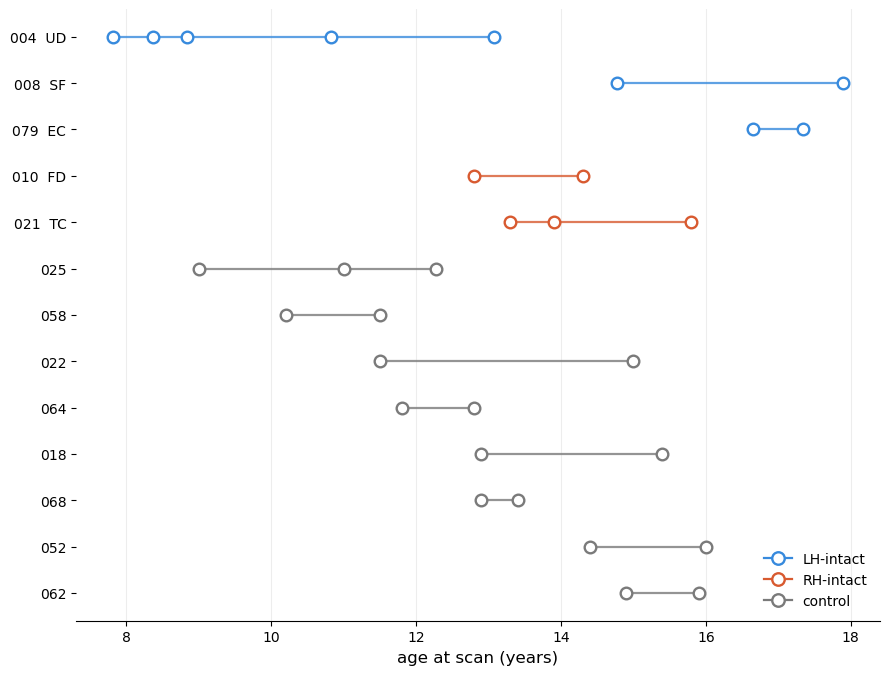

In [9]:
# ── Scan timeline: OTC and controls ───────────────────────────────────────
si=pd.read_csv(SUBINFO); si['subject_id']=si['sub'].astype(str)
si['ses_num']=pd.to_numeric(si['ses'].astype(str).str.extract(r'(\d+)',expand=False),
                            errors='coerce')
si=si[~si.subject_id.isin(EXCLUDE)]
for s_,x_ in EXCLUDE_SES: si=si[~((si.subject_id==s_)&(si.ses_num==x_))]
si=si[si.group.isin(['control','OTC'])]
nn=si.groupby('subject_id').ses_num.nunique(); si=si[si.subject_id.isin(nn[nn>=2].index)]
si['grp']=np.where(si.group=='control','control',
                   np.where(si.intact_hemi=='left','LH-intact','RH-intact'))
GORD=['LH-intact','RH-intact','control']
o=si.groupby(['grp','subject_id']).age.min().reset_index()
o['k']=o.grp.map({g:i for i,g in enumerate(GORD)})
o=o.sort_values(['k','age']).reset_index(drop=True)
CODE={'sub-004':'UD','sub-021':'TC','sub-010':'FD','sub-079':'EC','sub-008':'SF'}
fig,ax=plt.subplots(figsize=(9,0.42*len(o)+1.4)); fig.patch.set_facecolor('white')
for y,r in o.iterrows():
    g=si[si.subject_id==r.subject_id].sort_values('age')
    ax.plot(g.age,[y]*len(g),'-',color=GC[r.grp],lw=1.6,alpha=.8,zorder=2)
    ax.scatter(g.age,[y]*len(g),s=70,facecolors='white',edgecolors=GC[r.grp],lw=1.7,zorder=3)
ax.set_yticks(range(len(o)))
ax.set_yticklabels([(s_.replace('sub-','')+'  '+CODE.get(s_,'')).strip() for s_ in o.subject_id],
                   fontsize=10)
ax.invert_yaxis(); ax.set_xlabel('age at scan (years)',fontsize=12)
ax.xaxis.grid(True,color='#ededed',lw=0.8); ax.set_axisbelow(True)
for sp in ('top','right','left'): ax.spines[sp].set_visible(False)
ax.legend(handles=[Line2D([0],[0],marker='o',color=GC[k],markerfacecolor='white',
          markeredgewidth=1.7,markersize=9,lw=1.6,label=k) for k in GORD],
          frameon=False,fontsize=10,loc='lower right')
fig.tight_layout(); fig.savefig(FIGDIR/'long_scan_timeline.png',dpi=220,bbox_inches='tight')
plt.show(); plt.close(fig)

peak_location


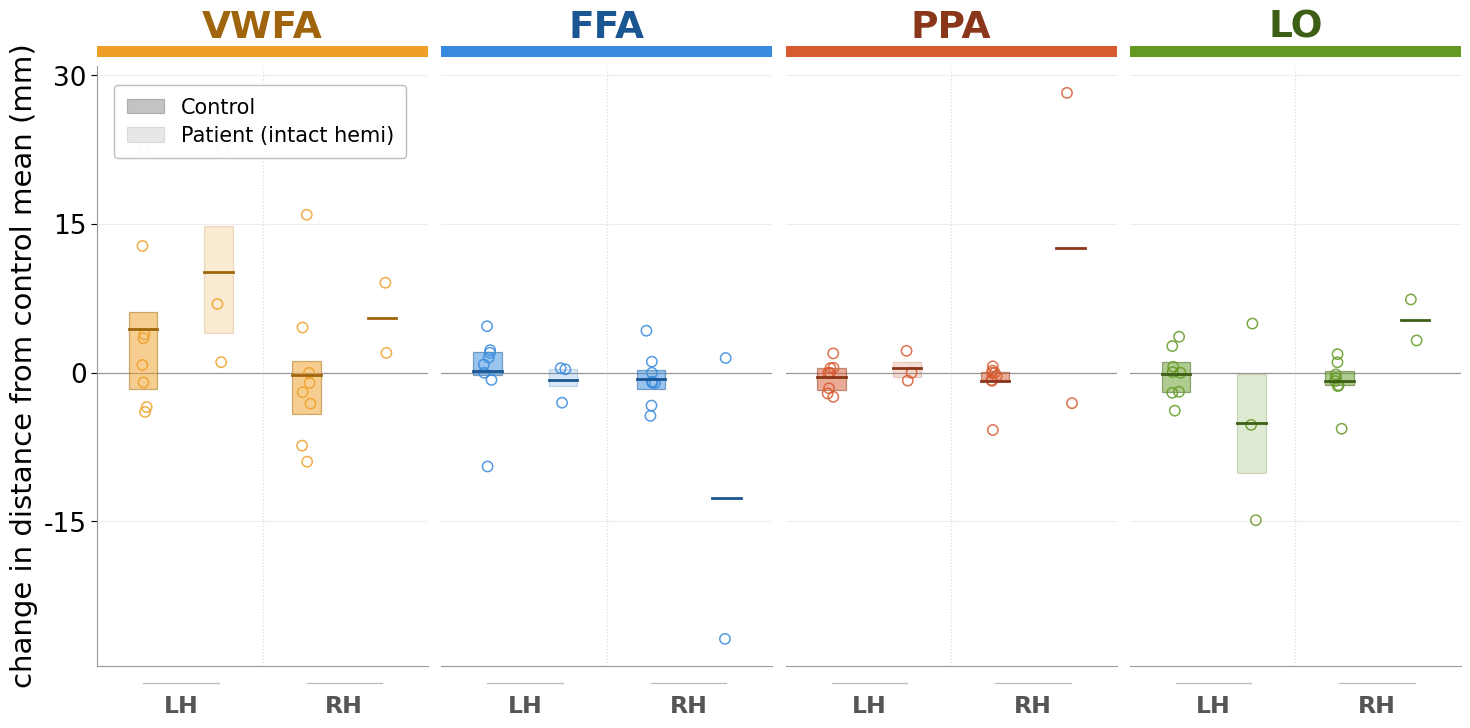

peak_movement


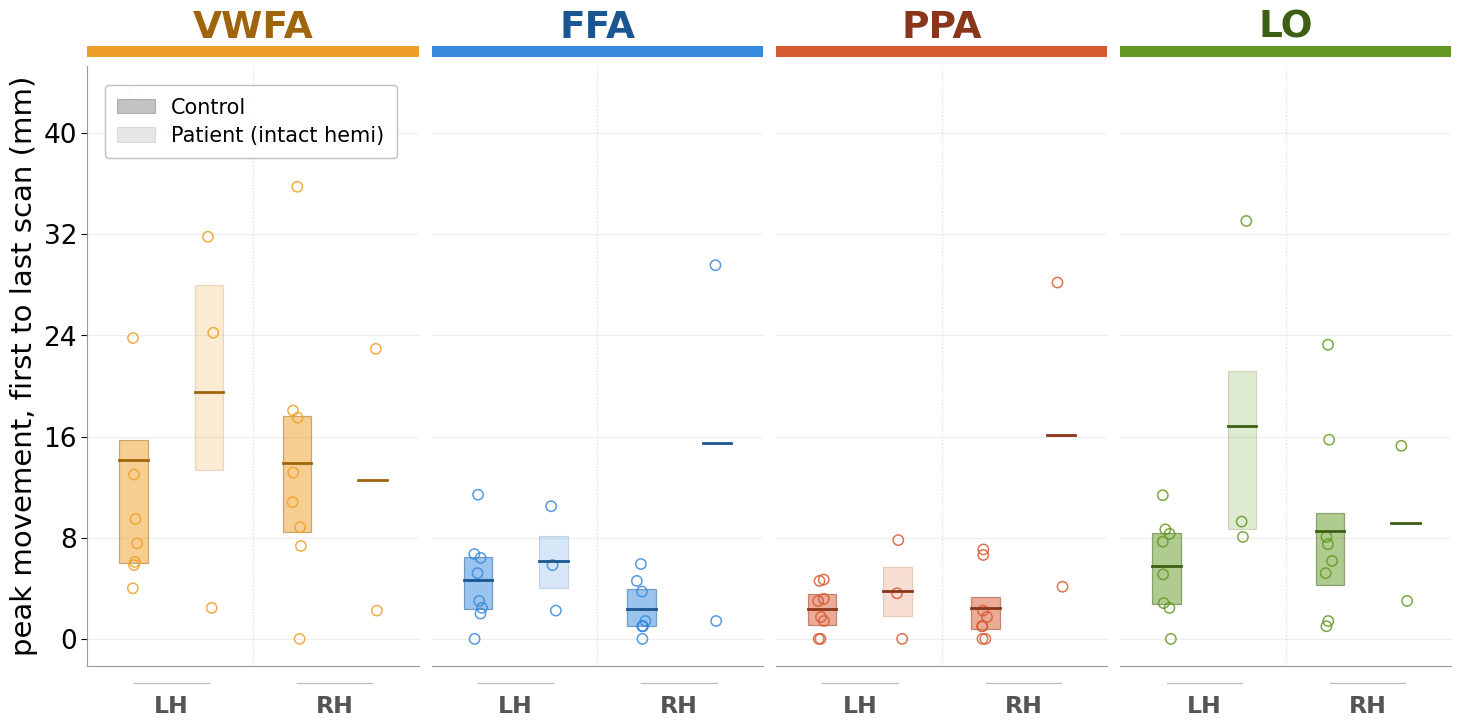

peak_selectivity


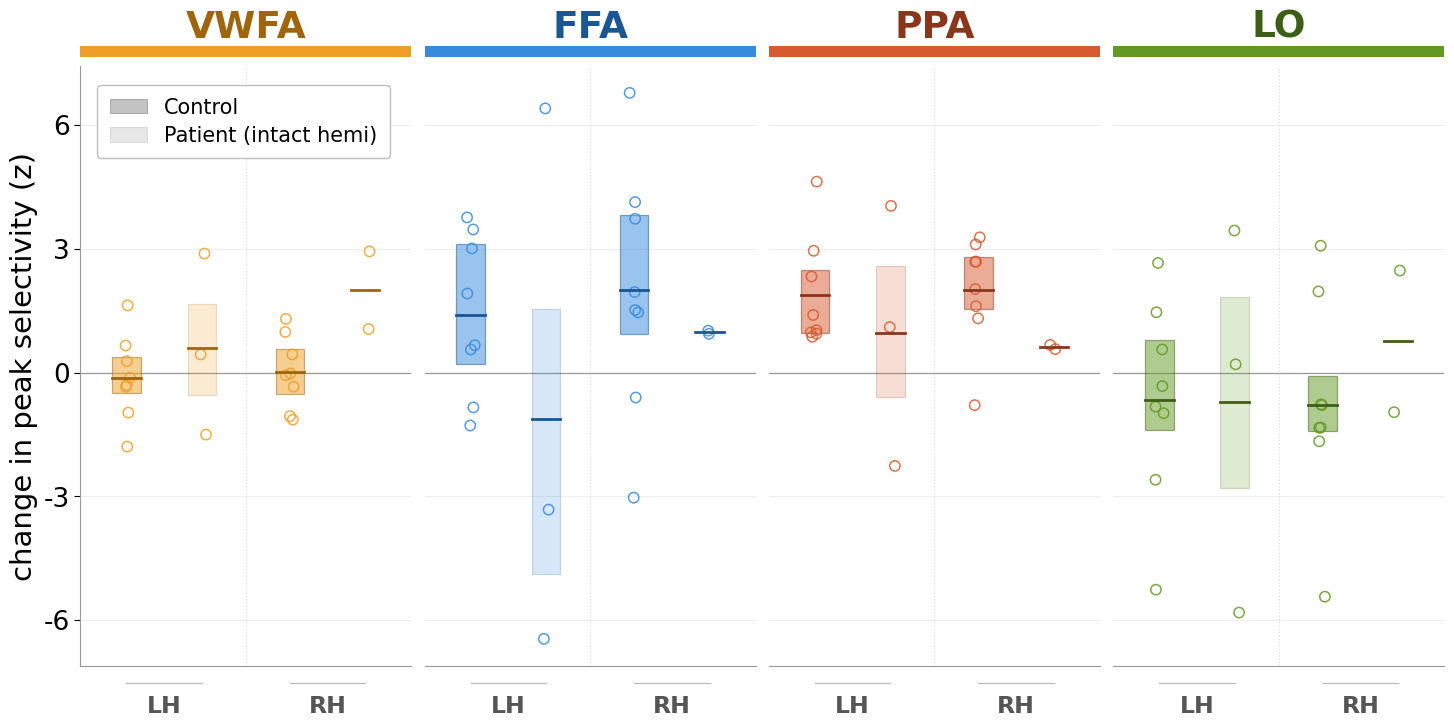

voxel_count_sqrt


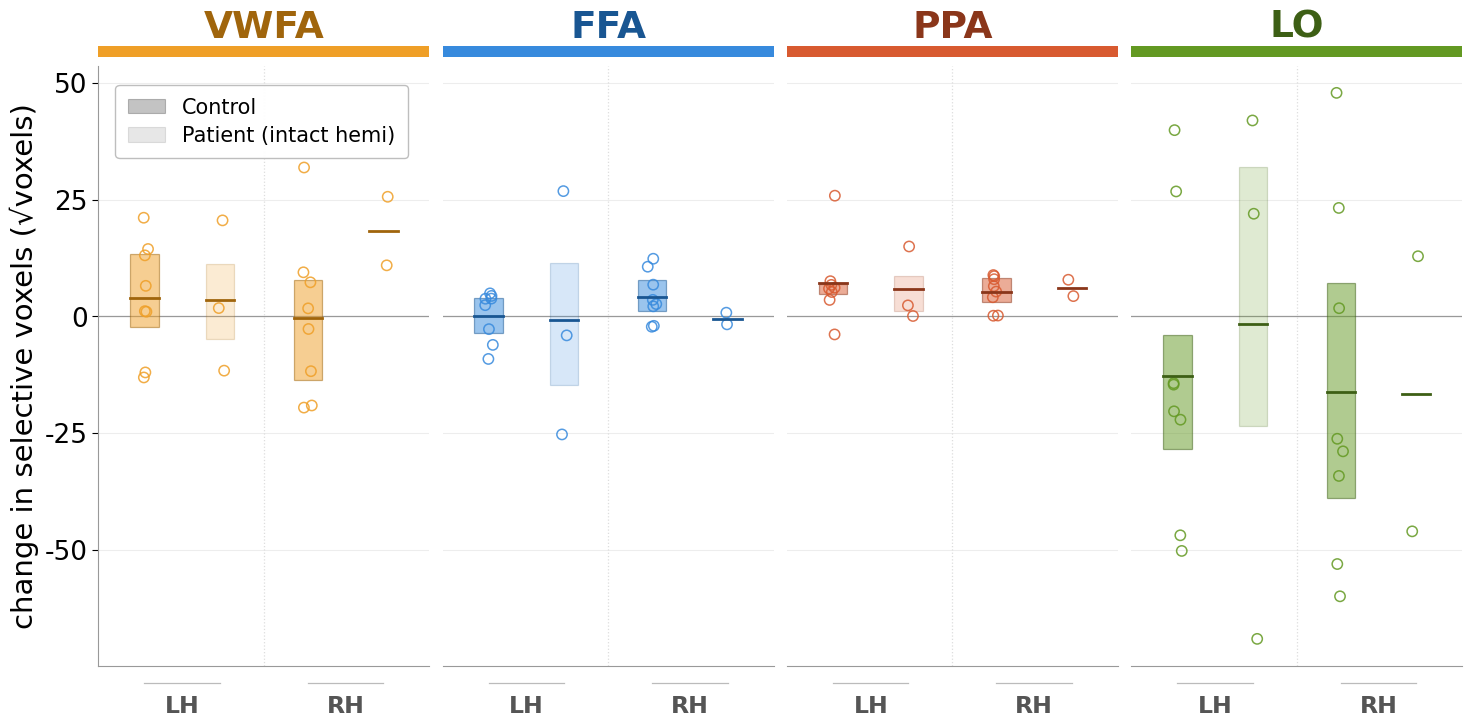

mean_between


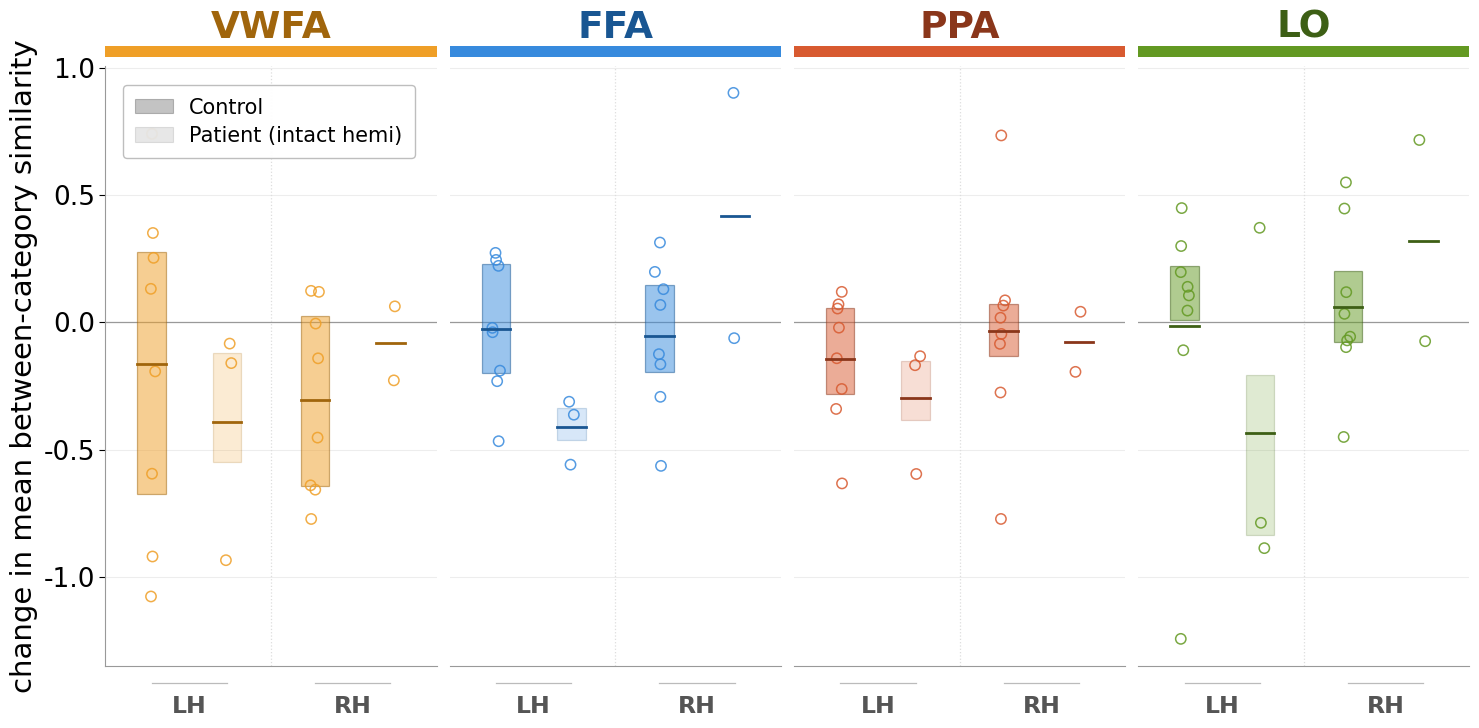

geometry


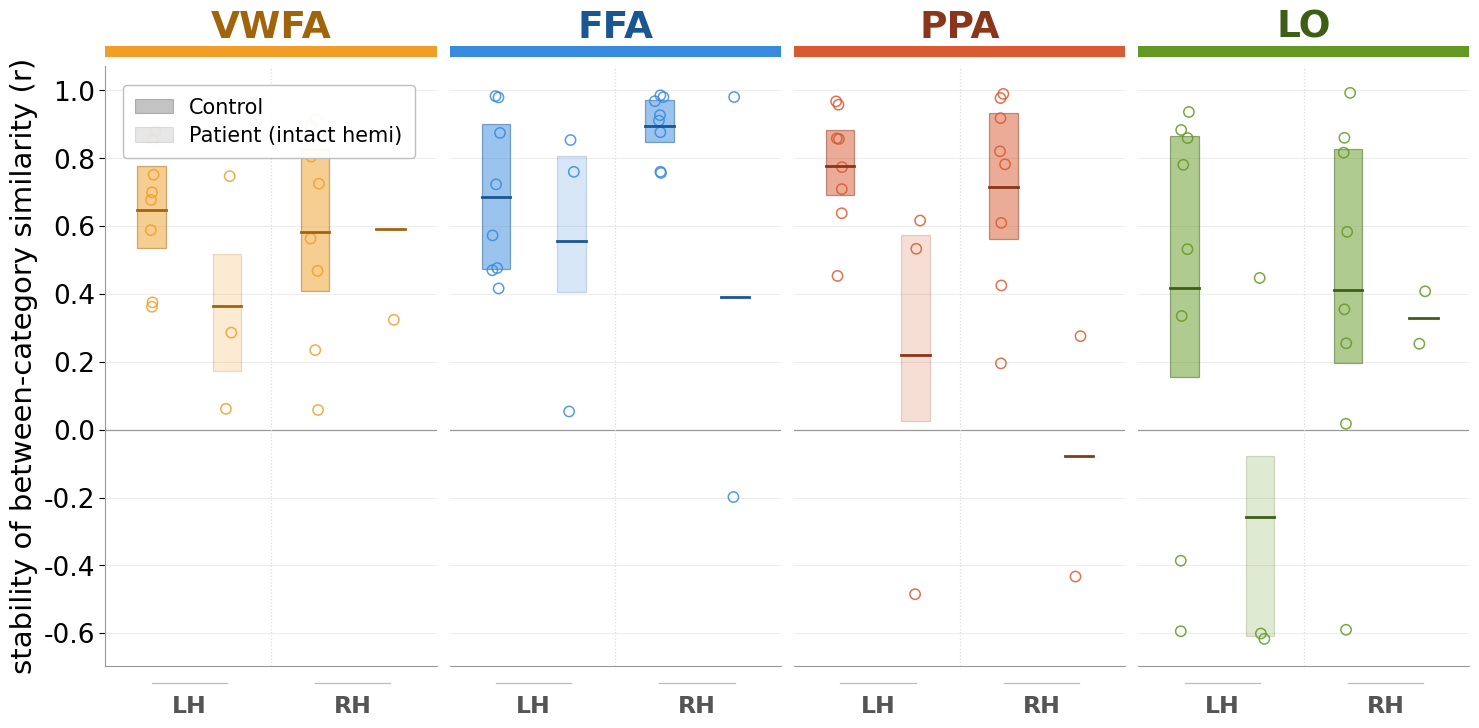

In [10]:
# ── Measure panels, paper style ──────────────────────────────────────────
PANELS=[('peak_location','change in distance from control mean (mm)',True),
        ('peak_movement','peak movement, first to last scan (mm)',False),
        ('peak_selectivity','change in peak selectivity (z)',True),
        ('voxel_count_sqrt','change in selective voxels (√voxels)',True),
        ('mean_between','change in mean between-category similarity',True),
        ('geometry','stability of between-category similarity (r)',True)]
for m,ylab,zl in PANELS:
    if m in CH and len(CH[m]):
        print(m); panel_row(getter(CH[m]),ylab,'long_'+m+'.png',zero_line=zl)

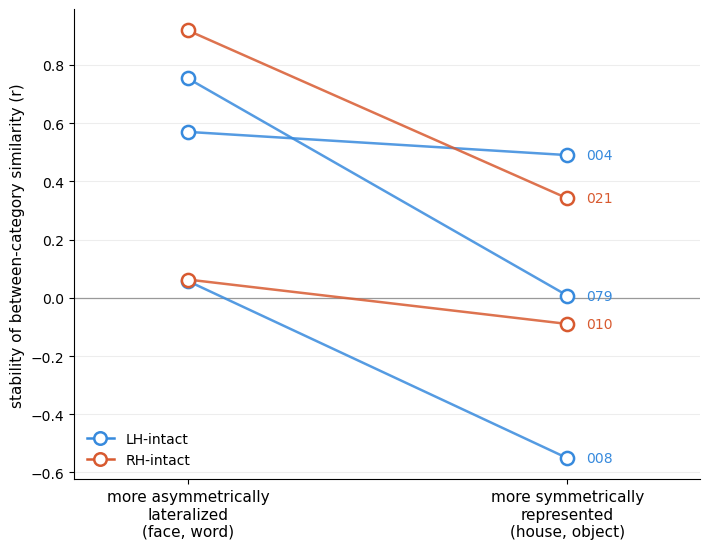

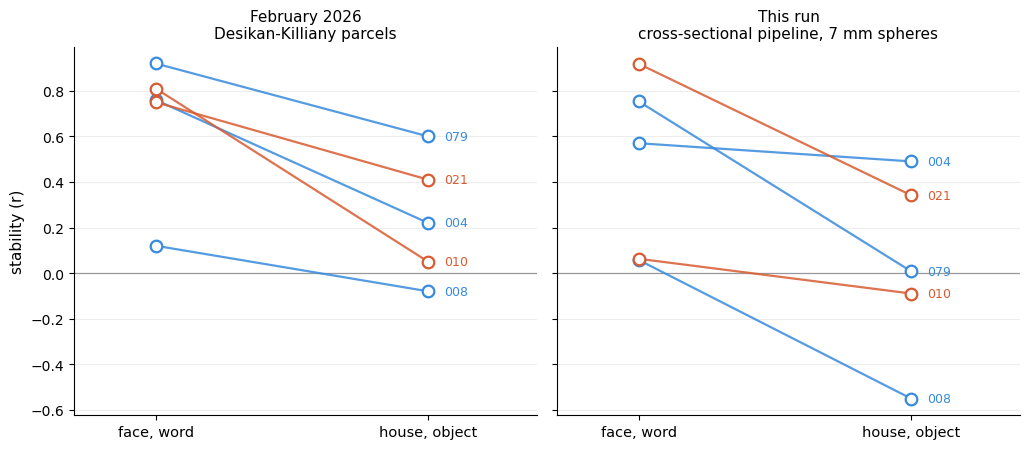

In [11]:
# ── Headline: stability of between-category similarity, sym vs asym ──────
g=CH['geometry']; pts=g[(g.status!='control')&(g.category.isin(ROIS))]
fig,ax=plt.subplots(figsize=(7.2,5.6)); fig.patch.set_facecolor('white')
ax.yaxis.grid(True,color='#ededed',lw=0.8); ax.set_axisbelow(True)
ax.axhline(0,color='#999',lw=0.9)
for s_,gg in pts.groupby('subject_id'):
    v=gg.set_index('category').delta
    a=np.mean([v['face_FFA'],v['word_VWFA']]); b=np.mean([v['house_PPA_strict'],v['object_LOC']])
    c=GC[gg.grp.iloc[0]]
    ax.plot([0,1],[a,b],'-',color=c,lw=1.8,alpha=.85)
    ax.scatter([0,1],[a,b],s=90,facecolors='white',edgecolors=c,lw=1.8,zorder=3)
    ax.text(1.05,b,s_.replace('sub-',''),va='center',fontsize=10,color=c)
ax.set_xlim(-.3,1.35); ax.set_xticks([0,1])
ax.set_xticklabels(['more asymmetrically\nlateralized\n(face, word)',
                    'more symmetrically\nrepresented\n(house, object)'],fontsize=11)
ax.set_ylabel('stability of between-category similarity (r)',fontsize=11)
for sp in ('top','right'): ax.spines[sp].set_visible(False)
ax.legend(handles=[Line2D([0],[0],marker='o',color=GC[k],markerfacecolor='white',
          markeredgewidth=1.8,markersize=9,lw=1.8,label=k) for k in ('LH-intact','RH-intact')],
          frameon=False,fontsize=10,loc='lower left')
fig.tight_layout(); fig.savefig(FIGDIR/'long_stability_sym_asym.png',dpi=220,bbox_inches='tight')
plt.show(); plt.close(fig)

# February versus now
FEB_PAIR={'sub-004':(0.76,0.22),'sub-008':(0.12,-0.08),'sub-079':(0.92,0.60),
          'sub-010':(0.81,0.05),'sub-021':(0.75,0.41)}
fig,axes=plt.subplots(1,2,figsize=(10.4,4.6),sharey=True); fig.patch.set_facecolor('white')
now={}
for s_,gg in pts.groupby('subject_id'):
    v=gg.set_index('category').delta
    now[s_]=(np.mean([v['face_FFA'],v['word_VWFA']]),np.mean([v['house_PPA_strict'],v['object_LOC']]))
INT={s_:gg.grp.iloc[0] for s_,gg in pts.groupby('subject_id')}
for ax,(title,src) in zip(axes,[('February 2026\nDesikan-Killiany parcels',FEB_PAIR),
                                ('This run\ncross-sectional pipeline, 7 mm spheres',now)]):
    ax.yaxis.grid(True,color='#ededed',lw=0.8); ax.set_axisbelow(True)
    ax.axhline(0,color='#999',lw=0.9)
    for s_,(a,b) in src.items():
        c=GC[INT.get(s_,'LH-intact')]
        ax.plot([0,1],[a,b],'-',color=c,lw=1.6,alpha=.85)
        ax.scatter([0,1],[a,b],s=70,facecolors='white',edgecolors=c,lw=1.6,zorder=3)
        ax.text(1.06,b,s_.replace('sub-',''),va='center',fontsize=9,color=c)
    ax.set_xlim(-.3,1.4); ax.set_xticks([0,1])
    ax.set_xticklabels(['face, word','house, object'],fontsize=10.5); ax.set_title(title,fontsize=11)
    for sp in ('top','right'): ax.spines[sp].set_visible(False)
axes[0].set_ylabel('stability (r)',fontsize=11)
fig.tight_layout(); fig.savefig(FIGDIR/'long_feb_vs_now.png',dpi=220,bbox_inches='tight')
plt.show(); plt.close(fig)

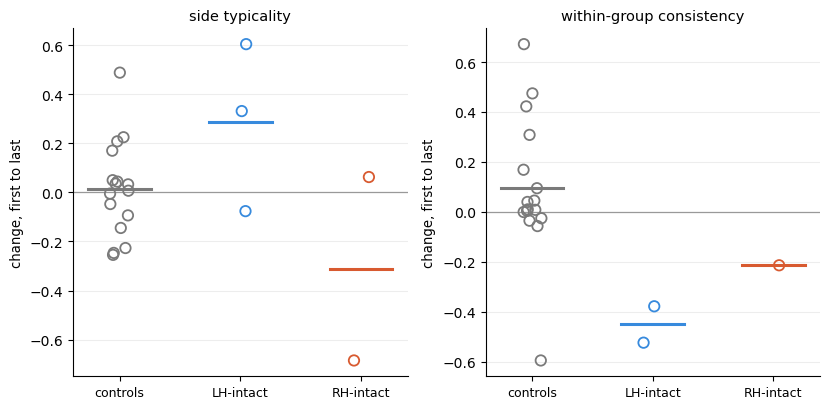

In [12]:
# ── Q1: side typicality and consistency ──────────────────────────────────
if 'side_typicality' in CH and len(CH['side_typicality']):
    fig,axes=plt.subplots(1,2,figsize=(8.4,4.2)); fig.patch.set_facecolor('white')
    for ax,m,t in [(axes[0],'side_typicality','side typicality'),
                   (axes[1],'consistency','within-group consistency')]:
        if m not in CH or not len(CH[m]): continue
        ch=CH[m]; ax.axhline(0,color='#999',lw=0.9)
        ax.yaxis.grid(True,color='#ededed',lw=0.8); ax.set_axisbelow(True)
        for xi,gname in enumerate(['control','LH-intact','RH-intact']):
            v=ch[ch.grp==gname].delta.dropna().values
            if len(v)==0: continue
            ax.scatter(np.full(len(v),xi)+RNG.uniform(-.08,.08,len(v)),v,s=56,
                       facecolors='none',edgecolors=GC[gname],lw=1.3,zorder=3)
            ax.plot([xi-.26,xi+.26],[v.mean()]*2,color=GC[gname],lw=2.2,zorder=4)
        ax.set_xticks(range(3)); ax.set_xticklabels(['controls','LH-intact','RH-intact'],fontsize=9)
        ax.set_title(t,fontsize=10.5); ax.set_ylabel('change, first to last',fontsize=9.5)
        for sp in ('top','right'): ax.spines[sp].set_visible(False)
    fig.tight_layout(); fig.savefig(FIGDIR/'long_q1_typicality.png',dpi=200,bbox_inches='tight')
    plt.show(); plt.close(fig)
else:
    print('Q1 figure skipped: side typicality not computed')

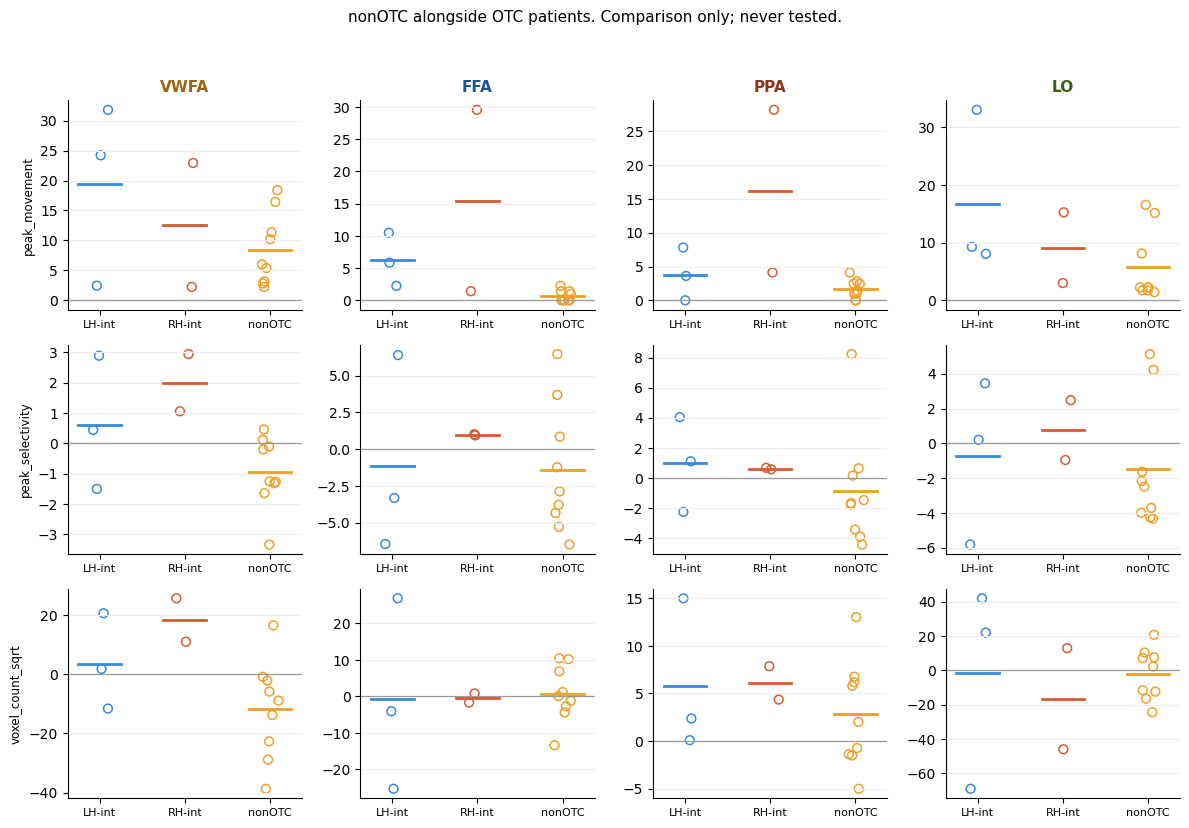

figures in /user_data/csimmon2/git_repos/sym_pt/C_results/figures/longitudinal_final


In [13]:
# ── nonOTC, visual comparison only ───────────────────────────────────────
MS=[m for m in ['peak_movement','peak_selectivity','voxel_count_sqrt'] if m in CH and len(CH[m])]
fig,axes=plt.subplots(len(MS),4,figsize=(12,2.8*len(MS)),squeeze=False)
fig.patch.set_facecolor('white')
for ri,m in enumerate(MS):
    ch=CH[m]
    for ci,roi in enumerate(ROI_ORDER):
        ax=axes[ri][ci]; base=CAT_COLORS[ROI_CAT[roi]]
        ax.axhline(0,color='#999',lw=0.9); ax.yaxis.grid(True,color='#ededed',lw=0.8)
        for xi,gname in enumerate(['LH-intact','RH-intact','nonOTC']):
            v=ch[(ch.grp==gname)&(ch.category==roi)].delta.dropna().values
            if len(v)==0: continue
            ax.scatter(np.full(len(v),xi)+RNG.uniform(-.1,.1,len(v)),v,s=40,facecolors='none',
                       edgecolors=GC[gname],lw=1.1)
            ax.plot([xi-.25,xi+.25],[v.mean()]*2,color=GC[gname],lw=2)
        ax.set_xticks(range(3)); ax.set_xticklabels(['LH-int','RH-int','nonOTC'],fontsize=8)
        if ri==0: ax.set_title(ROI_TITLE[roi],fontsize=11,color=shade(base,0.62),fontweight='bold')
        if ci==0: ax.set_ylabel(m,fontsize=8.5)
        for sp in ('top','right'): ax.spines[sp].set_visible(False)
fig.suptitle('nonOTC alongside OTC patients. Comparison only; never tested.',fontsize=11)
fig.tight_layout(rect=[0,0,1,.95])
fig.savefig(FIGDIR/'long_nonotc_visual.png',dpi=200,bbox_inches='tight'); plt.show(); plt.close(fig)
print('figures in',FIGDIR)

## End

Outstanding items are listed in the header.